# Обучение модели локализации паттерна "Голова и Плечи"

Ноутбук для полного цикла:
1. Загрузка и подготовка данных
2. Обучение CNN-LSTM модели с локализацией
3. Визуализация паттернов на валидационной выборке

## 1. Импорт библиотек и конфигурация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
from tqdm import tqdm
import seaborn as sns

from model_architecture import CNNLSTMLocalizationModel

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Конфигурация
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 0.001
LAMBDA_LOC = 0.5
WINDOW_SIZE = 120
VAL_SPLIT = 0.2

print(f"Устройство: {DEVICE}")
print(f"GPU доступен: {torch.cuda.is_available()}")

Устройство: cpu
GPU доступен: False


## 2. Загрузка и подготовка данных

In [2]:
print("Загрузка данных...")

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Разделение признаков и меток
feature_cols = [col for col in train_df.columns if col.startswith('t')]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['has_pattern'].values.astype(np.float32)
start_train = train_df['pattern_start'].values.astype(np.float32)
end_train = train_df['pattern_end'].values.astype(np.float32)

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['has_pattern'].values.astype(np.float32)
start_test = test_df['pattern_start'].values.astype(np.float32)
end_test = test_df['pattern_end'].values.astype(np.float32)

# Преобразование для Conv1D (batch, channels, timesteps)
X_train = X_train.reshape(-1, 1, X_train.shape[1])
X_test = X_test.reshape(-1, 1, X_test.shape[1])

print(f"✓ Размер обучающего набора: X={X_train.shape}, y={y_train.shape}")
print(f"✓ Размер тестового набора: X={X_test.shape}, y={y_test.shape}")
print(f"✓ Распределение классов в обучении:")
print(f"  - С паттерном: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")
print(f"  - Без паттерна: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")

Загрузка данных...
✓ Размер обучающего набора: X=(1372, 1, 120), y=(1372,)
✓ Размер тестового набора: X=(344, 1, 120), y=(344,)
✓ Распределение классов в обучении:
  - С паттерном: 504 (36.7%)
  - Без паттерна: 868 (63.3%)


## 3. Создание DataLoader'ов

In [3]:
# Преобразование в тензоры
X_train_tensor = torch.FloatTensor(X_train).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train).to(DEVICE)
start_train_tensor = torch.FloatTensor(start_train).to(DEVICE)
end_train_tensor = torch.FloatTensor(end_train).to(DEVICE)

X_test_tensor = torch.FloatTensor(X_test).to(DEVICE)
y_test_tensor = torch.FloatTensor(y_test).to(DEVICE)

# Разделение на обучение и валидацию
np.random.seed(42)
val_size = int(len(X_train_tensor) * VAL_SPLIT)
val_indices = np.random.choice(len(X_train_tensor), val_size, replace=False)
train_indices = np.array([i for i in range(len(X_train_tensor)) if i not in val_indices])

X_train_split = X_train_tensor[train_indices]
y_train_split = y_train_tensor[train_indices]
start_train_split = start_train_tensor[train_indices]
end_train_split = end_train_tensor[train_indices]

X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]
start_val = start_train_tensor[val_indices]
end_val = end_train_tensor[val_indices]

# Сохраняем валидационные данные для позже (для визуализации)
X_val_np = X_val.cpu().numpy()
y_val_np = y_val.cpu().numpy()
start_val_np = start_val.cpu().numpy()
end_val_np = end_val.cpu().numpy()

# Создание DataLoader'ов
train_dataset = TensorDataset(X_train_split, y_train_split, start_train_split, end_train_split)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"✓ Размер тренировочного батча: {len(X_train_split)}")
print(f"✓ Размер валидационного батча: {len(X_val)}")
print(f"✓ Количество батчей: {len(train_loader)}")

✓ Размер тренировочного батча: 1098
✓ Размер валидационного батча: 274
✓ Количество батчей: 35


## 4. Создание модели

In [4]:
print("Создание модели CNN-LSTM с локализацией...\n")

model = CNNLSTMLocalizationModel().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")
print(f"\nВыходы модели:")
print(f"  1. class_out - вероятность паттерна [0-1]")
print(f"  2. start_out - нормализованное начало [0-1]")
print(f"  3. end_out   - нормализованный конец [0-1]")
print(f"\nПараметры обучения:")
print(f"  - Эпохи: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Lambda (вес локализации): {LAMBDA_LOC}")
print(f"  - Early stopping patience: {PATIENCE}")

Создание модели CNN-LSTM с локализацией...

Всего параметров: 64,963
Обучаемых параметров: 64,963

Выходы модели:
  1. class_out - вероятность паттерна [0-1]
  2. start_out - нормализованное начало [0-1]
  3. end_out   - нормализованный конец [0-1]

Параметры обучения:
  - Эпохи: 100
  - Batch size: 32
  - Learning rate: 0.001
  - Lambda (вес локализации): 0.5
  - Early stopping patience: 15


## 5. Функции для обучения и валидации

In [5]:
def train_epoch(model, train_loader, optimizer, criterion_class, criterion_loc, lambda_loc):
    """Обучение на одной эпохе"""
    model.train()
    total_loss = 0.0
    class_loss_sum = 0.0
    loc_loss_sum = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch, start_batch, end_batch in train_loader:
        optimizer.zero_grad()
        
        # Предсказания
        class_pred, start_pred, end_pred = model(X_batch)
        
        # Потеря классификации
        loss_class = criterion_class(class_pred, y_batch.view(-1, 1))
        
        # Потеря локализации (только для образцов с паттерном)
        mask = y_batch.view(-1, 1) > 0.5
        if mask.sum() > 0:
            loss_loc = criterion_loc(start_pred[mask], start_batch.view(-1, 1)[mask]) + \
                       criterion_loc(end_pred[mask], end_batch.view(-1, 1)[mask])
        else:
            loss_loc = torch.tensor(0.0, device=DEVICE)
        
        # Общая потеря
        loss = loss_class + lambda_loc * loss_loc
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        class_loss_sum += loss_class.item()
        if mask.sum() > 0:
            loc_loss_sum += loss_loc.item()
        
        correct += ((class_pred > 0.5).float() == y_batch.view(-1, 1)).sum().item()
        total += y_batch.size(0)
    
    avg_loss = total_loss / len(train_loader)
    avg_class_loss = class_loss_sum / len(train_loader)
    avg_loc_loss = loc_loss_sum / len(train_loader) if loc_loss_sum > 0 else 0.0
    accuracy = correct / total
    
    return avg_loss, avg_class_loss, avg_loc_loss, accuracy


def validate(model, X_val, y_val, start_val, end_val, criterion_class, criterion_loc, lambda_loc):
    """Валидация модели"""
    model.eval()
    with torch.no_grad():
        class_pred, start_pred, end_pred = model(X_val)
        
        loss_class = criterion_class(class_pred, y_val.view(-1, 1))
        
        mask = y_val.view(-1, 1) > 0.5
        if mask.sum() > 0:
            loss_loc = criterion_loc(start_pred[mask], start_val.view(-1, 1)[mask]) + \
                       criterion_loc(end_pred[mask], end_val.view(-1, 1)[mask])
        else:
            loss_loc = torch.tensor(0.0, device=DEVICE)
        
        total_loss = loss_class + lambda_loc * loss_loc
        
        correct = ((class_pred > 0.5).float() == y_val.view(-1, 1)).sum().item()
        accuracy = correct / y_val.size(0)
        
    return total_loss.item(), loss_class.item(), loss_loc.item() if loss_loc.item() > 0 else 0.0, accuracy

print("✓ Функции обучения и валидации определены")

✓ Функции обучения и валидации определены


## 6. Обучение модели

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion_class = nn.BCELoss()
criterion_loc = nn.SmoothL1Loss()

best_val_loss = float('inf')
patience_counter = 0
history = {
    'train_loss': [],
    'train_class_loss': [],
    'train_loc_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_class_loss': [],
    'val_loc_loss': [],
    'val_acc': []
}

print(f"Обучение модели (эпохи: {EPOCHS}, patience: {PATIENCE})\n")
print(f"{'Эпоха':<6} {'Train Loss':<14} {'Val Loss':<14} {'Train Acc':<12} {'Val Acc':<12} {'Status':<10}")
print("-" * 80)

for epoch in range(EPOCHS):
    # Обучение
    train_loss, train_class_loss, train_loc_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion_class, criterion_loc, LAMBDA_LOC
    )
    
    # Валидация
    val_loss, val_class_loss, val_loc_loss, val_acc = validate(
        model, X_val, y_val, start_val, end_val, criterion_class, criterion_loc, LAMBDA_LOC
    )
    
    # Сохранение в историю
    history['train_loss'].append(train_loss)
    history['train_class_loss'].append(train_class_loss)
    history['train_loc_loss'].append(train_loc_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_class_loss'].append(val_class_loss)
    history['val_loc_loss'].append(val_loc_loss)
    history['val_acc'].append(val_acc)
    
    # Ранняя остановка
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_loc.pt')
        status = "✓ SAVED"
    else:
        patience_counter += 1
        status = ""
    
    if (epoch + 1) % 10 == 0 or epoch == 0 or patience_counter >= PATIENCE:
        print(f"{epoch+1:<6} {train_loss:<14.4f} {val_loss:<14.4f} {train_acc:<12.4f} {val_acc:<12.4f} {status:<10}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠ Остановка на эпохе {epoch + 1} (patience={PATIENCE})")
        break

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model_loc.pt'))
print(f"\n✓ Обучение завершено! Всего эпох: {len(history['train_loss'])}")

Обучение модели (эпохи: 100, patience: 15)

Эпоха  Train Loss     Val Loss       Train Acc    Val Acc      Status    
--------------------------------------------------------------------------------
1      0.6985         0.6885         0.5893       0.6423       ✓ SAVED   
10     0.6422         0.6615         0.6803       0.6350       ✓ SAVED   
20     0.5669         0.5969         0.7468       0.7044       ✓ SAVED   
30     0.3888         0.4310         0.8379       0.8029       ✓ SAVED   
40     0.2261         0.4679         0.9226       0.8467                 
50     0.1775         0.4688         0.9399       0.8467                 
60     0.1413         0.4741         0.9572       0.8613                 

⚠ Остановка на эпохе 60 (patience=15)

✓ Обучение завершено! Всего эпох: 60


## 7. Визуализация графиков обучения

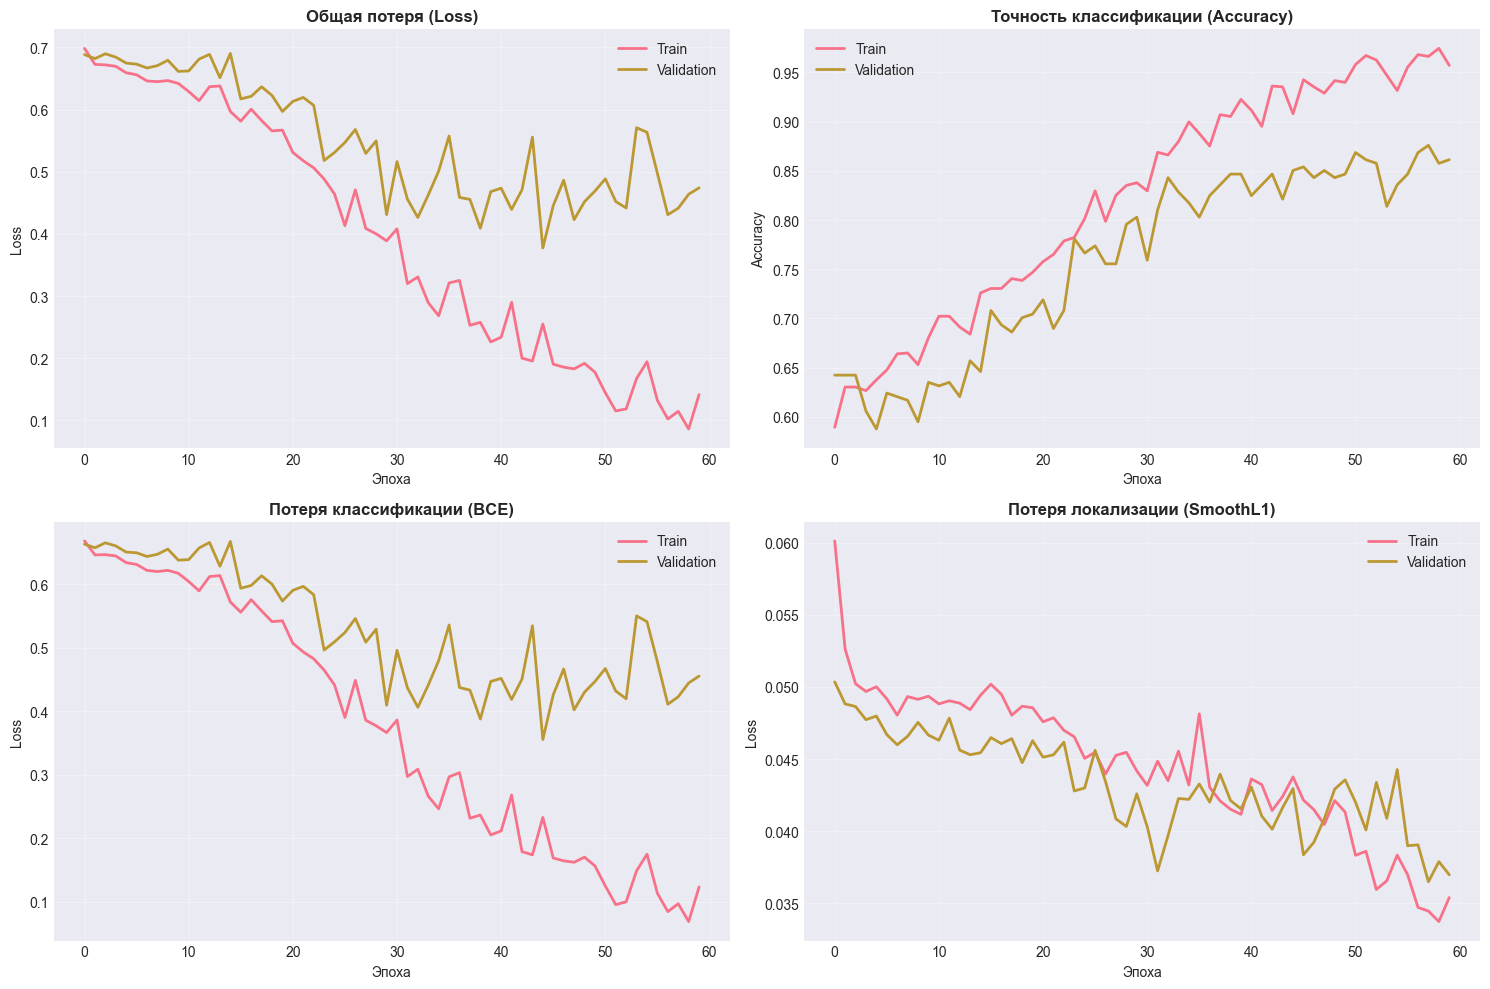

✓ Графики обучения сохранены в training_history.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('Общая потеря (Loss)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[0, 1].set_title('Точность классификации (Accuracy)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Classification Loss
axes[1, 0].plot(history['train_class_loss'], label='Train', linewidth=2)
axes[1, 0].plot(history['val_class_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('Потеря классификации (BCE)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Localization Loss
axes[1, 1].plot(history['train_loc_loss'], label='Train', linewidth=2)
axes[1, 1].plot(history['val_loc_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('Потеря локализации (SmoothL1)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Графики обучения сохранены в training_history.png")

## 8. Предсказания на валидационной выборке

In [8]:
# Получение предсказаний на валидационной выборке
model.eval()
with torch.no_grad():
    class_pred_val, start_pred_val, end_pred_val = model(X_val)
    
    class_pred_val_np = class_pred_val.squeeze().cpu().numpy()
    start_pred_val_np = start_pred_val.squeeze().cpu().numpy()
    end_pred_val_np = end_pred_val.squeeze().cpu().numpy()

# Денормализация координат в индексы
start_pred_idx = (start_pred_val_np * WINDOW_SIZE).astype(int)
end_pred_idx = (end_pred_val_np * WINDOW_SIZE).astype(int)
start_actual_idx = (start_val_np * WINDOW_SIZE).astype(int)
end_actual_idx = (end_val_np * WINDOW_SIZE).astype(int)

print(f"✓ Получены предсказания на валидационной выборке ({len(X_val)} образцов)")
print(f"\nПримеры предсказаний:")
print(f"{'ID':<5} {'Фактич':<10} {'Предсказ':<12} {'Нач пред':<12} {'Нач факт':<12} {'Конец пред':<12} {'Конец факт':<12}")
print("-" * 90)
for i in range(min(10, len(X_val))):
    print(f"{i:<5} {y_val_np[i]:<10.0f} {class_pred_val_np[i]:<12.4f} "
          f"{start_pred_idx[i]:<12} {start_actual_idx[i]:<12} "
          f"{end_pred_idx[i]:<12} {end_actual_idx[i]:<12}")

✓ Получены предсказания на валидационной выборке (274 образцов)

Примеры предсказаний:
ID    Фактич     Предсказ     Нач пред     Нач факт     Конец пред   Конец факт  
------------------------------------------------------------------------------------------
0     1          0.9528       35           13           64           57          
1     0          0.0018       35           -120         60           -120        
2     0          0.2990       35           -120         67           -120        
3     1          0.9903       36           23           67           54          
4     1          0.9868       54           38           85           73          
5     0          0.2504       35           -120         66           -120        
6     0          0.0003       40           -120         60           -120        
7     0          0.0977       58           -120         88           -120        
8     1          0.9916       36           6            71           52          
9 

## 9. Визуализация паттернов на валидационной выборке

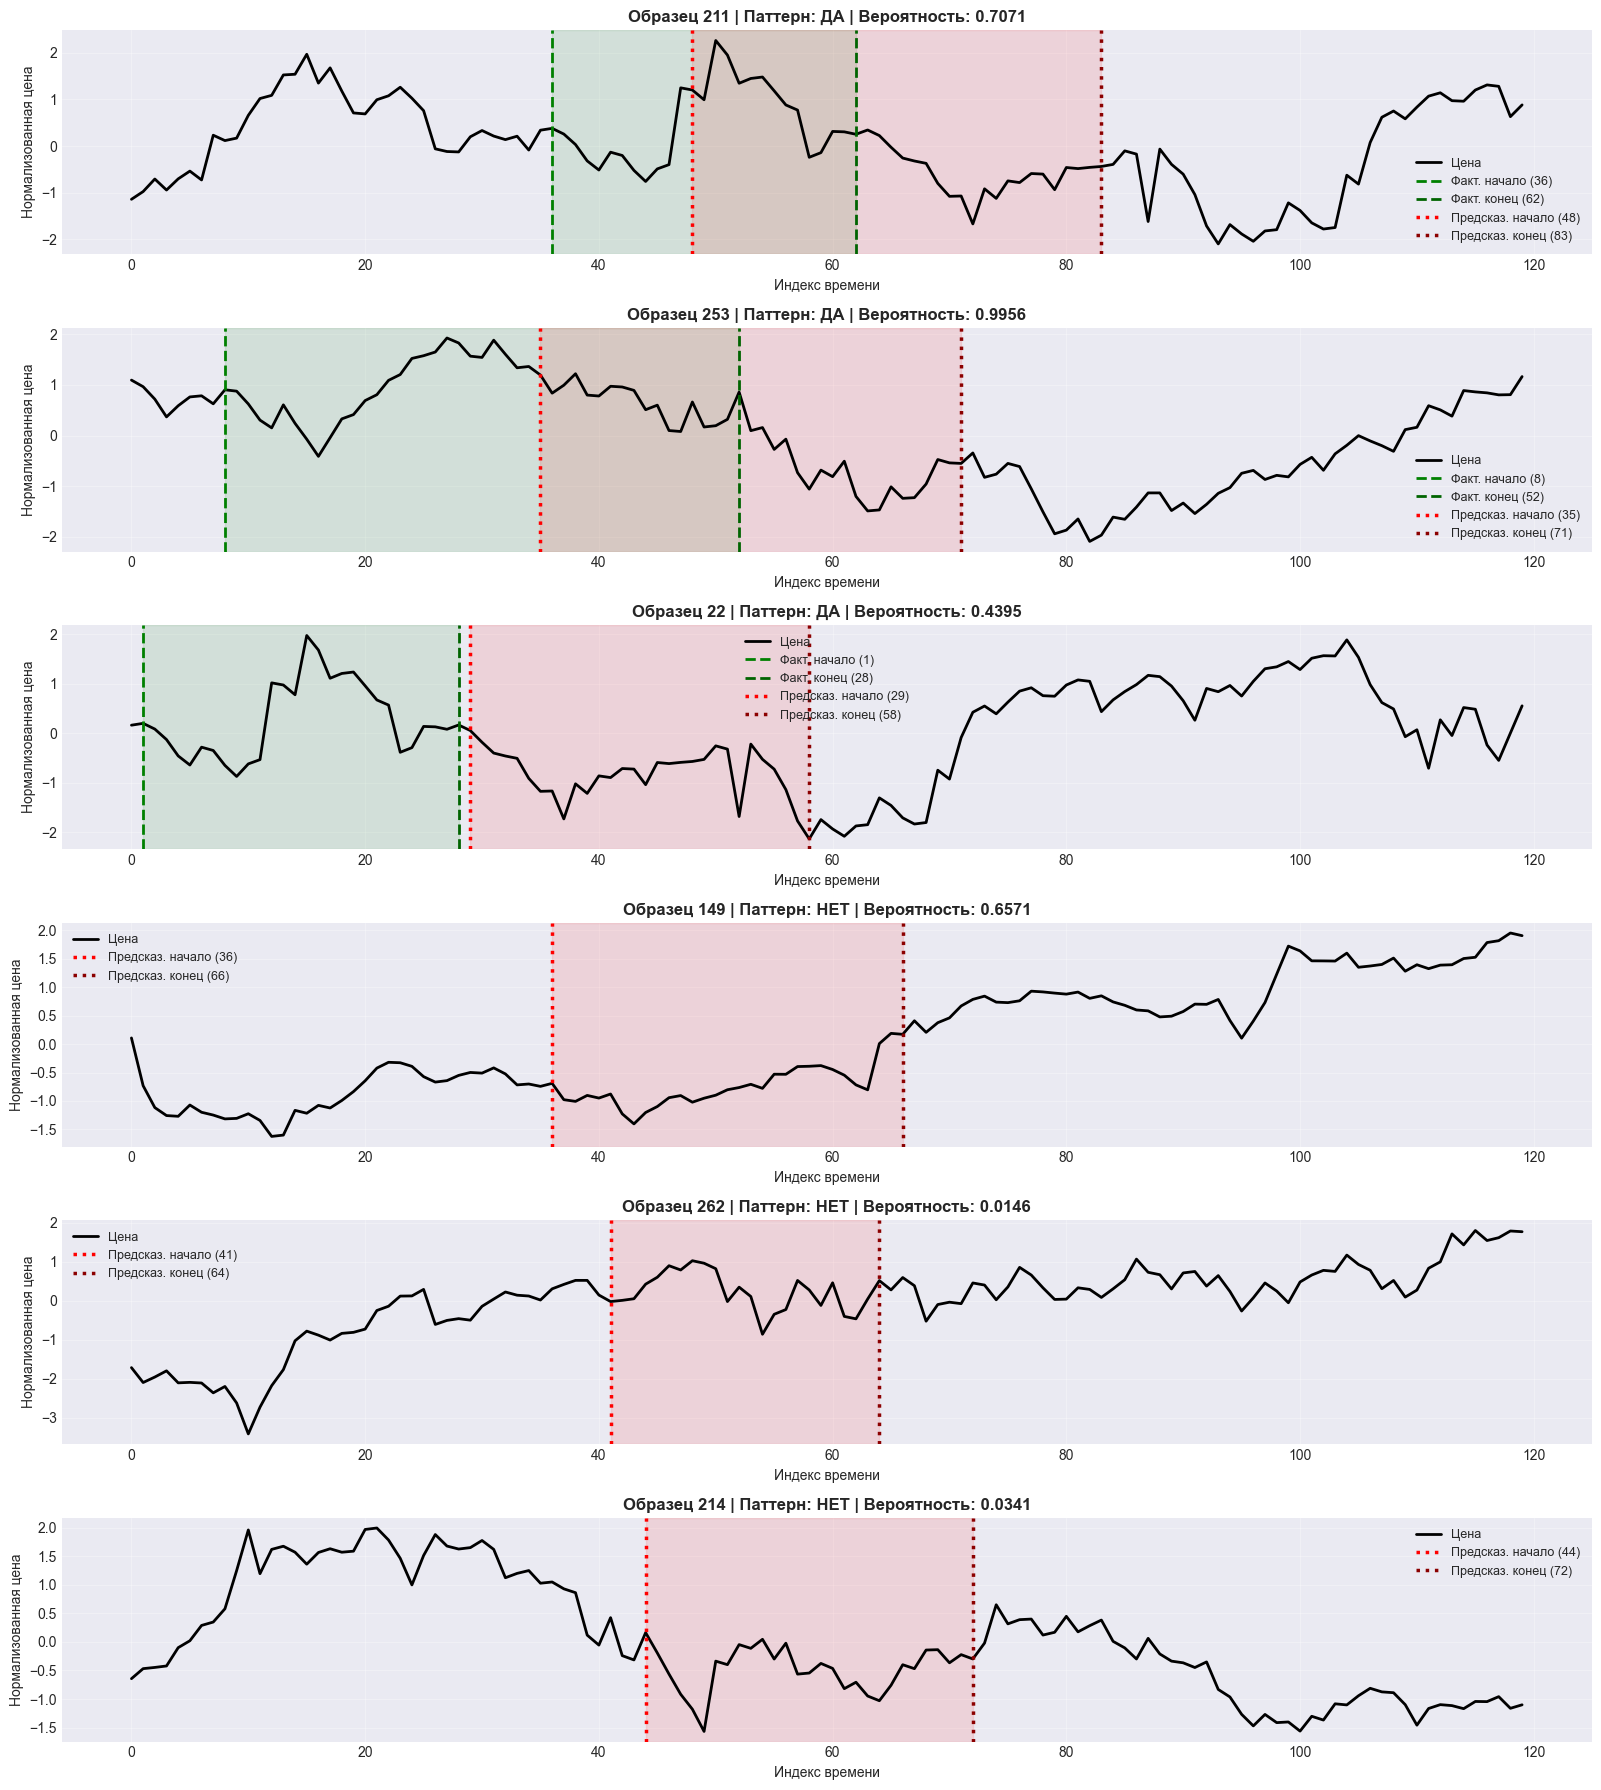

✓ Визуализация паттернов сохранена в pattern_predictions_validation.png


In [9]:
# Выбираем образцы с паттернами и без
pattern_indices = np.where(y_val_np == 1)[0]
no_pattern_indices = np.where(y_val_np == 0)[0]

# Берем по 3 примера каждого класса
selected_indices = np.concatenate([
    np.random.choice(pattern_indices, min(3, len(pattern_indices)), replace=False),
    np.random.choice(no_pattern_indices, min(3, len(no_pattern_indices)), replace=False)
])

fig, axes = plt.subplots(len(selected_indices), 1, figsize=(16, 3*len(selected_indices)))
if len(selected_indices) == 1:
    axes = [axes]

for plot_idx, sample_idx in enumerate(selected_indices):
    ax = axes[plot_idx]
    
    # Временный ряд
    time_series = X_val_np[sample_idx, 0, :]
    x_axis = np.arange(WINDOW_SIZE)
    
    ax.plot(x_axis, time_series, linewidth=2, label='Цена', color='black')
    
    # Если есть паттерн
    if y_val_np[sample_idx] == 1:
        # Фактические координаты
        ax.axvline(start_actual_idx[sample_idx], color='green', linestyle='--', linewidth=2, label=f'Факт. начало ({start_actual_idx[sample_idx]})')
        ax.axvline(end_actual_idx[sample_idx], color='darkgreen', linestyle='--', linewidth=2, label=f'Факт. конец ({end_actual_idx[sample_idx]})')
        ax.axvspan(start_actual_idx[sample_idx], end_actual_idx[sample_idx], alpha=0.1, color='green')
    
    # Предсказанные координаты
    ax.axvline(start_pred_idx[sample_idx], color='red', linestyle=':', linewidth=2.5, label=f'Предсказ. начало ({start_pred_idx[sample_idx]})')
    ax.axvline(end_pred_idx[sample_idx], color='darkred', linestyle=':', linewidth=2.5, label=f'Предсказ. конец ({end_pred_idx[sample_idx]})')
    ax.axvspan(start_pred_idx[sample_idx], end_pred_idx[sample_idx], alpha=0.1, color='red')
    
    # Заголовок
    title_text = f"Образец {sample_idx} | "
    if y_val_np[sample_idx] == 1:
        title_text += f"Паттерн: ДА | Вероятность: {class_pred_val_np[sample_idx]:.4f}"
    else:
        title_text += f"Паттерн: НЕТ | Вероятность: {class_pred_val_np[sample_idx]:.4f}"
    
    ax.set_title(title_text, fontsize=12, fontweight='bold')
    ax.set_xlabel('Индекс времени')
    ax.set_ylabel('Нормализованная цена')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pattern_predictions_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Визуализация паттернов сохранена в pattern_predictions_validation.png")

## 10. Детальная визуализация: 6 примеров с разными сценариями

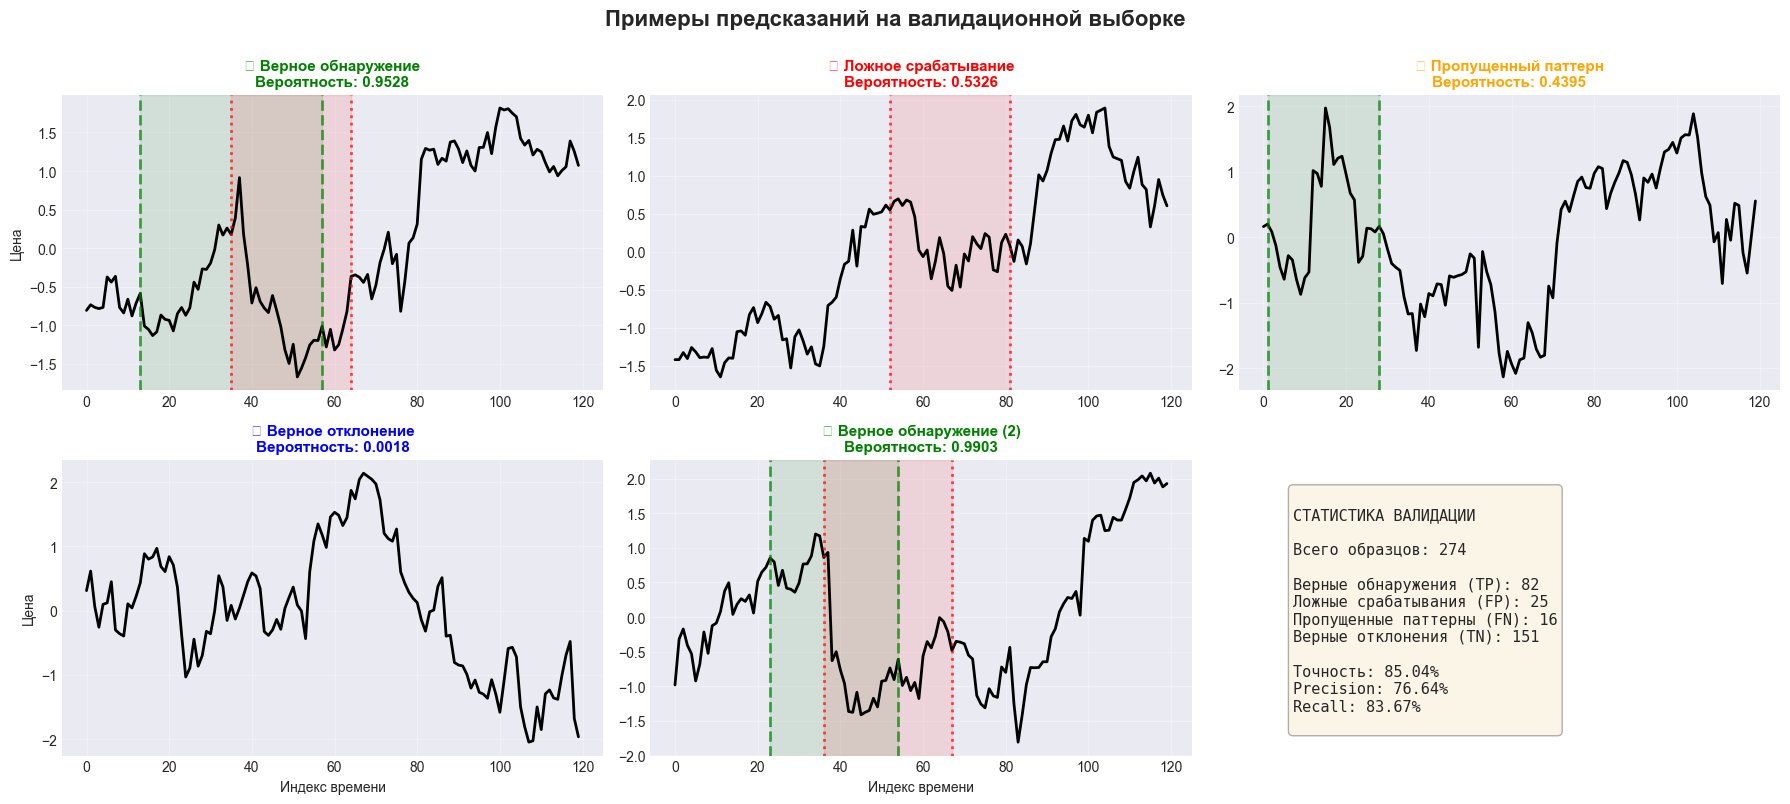

✓ Детальная визуализация сохранена в detailed_predictions.png


In [10]:
# Классификация предсказаний
y_pred_binary = (class_pred_val_np > 0.5).astype(int)

# Верные положительные
tp_indices = np.where((y_val_np == 1) & (y_pred_binary == 1))[0]
# Неверные положительные
fp_indices = np.where((y_val_np == 0) & (y_pred_binary == 1))[0]
# Неверные отрицательные
fn_indices = np.where((y_val_np == 1) & (y_pred_binary == 0))[0]
# Верные отрицательные
tn_indices = np.where((y_val_np == 0) & (y_pred_binary == 0))[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Примеры предсказаний на валидационной выборке', fontsize=16, fontweight='bold', y=1.00)

# TP
if len(tp_indices) > 0:
    idx = tp_indices[0]
    ax = axes[0, 0]
    ts = X_val_np[idx, 0, :]
    ax.plot(np.arange(WINDOW_SIZE), ts, linewidth=2, color='black')
    ax.axvline(start_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(end_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(start_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(end_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(start_actual_idx[idx], end_actual_idx[idx], alpha=0.1, color='green')
    ax.axvspan(start_pred_idx[idx], end_pred_idx[idx], alpha=0.1, color='red')
    ax.set_title(f"✓ Верное обнаружение\nВероятность: {class_pred_val_np[idx]:.4f}", 
                fontsize=11, fontweight='bold', color='green')
    ax.set_ylabel('Цена')
    ax.grid(True, alpha=0.3)

# FP
if len(fp_indices) > 0:
    idx = fp_indices[0]
    ax = axes[0, 1]
    ts = X_val_np[idx, 0, :]
    ax.plot(np.arange(WINDOW_SIZE), ts, linewidth=2, color='black')
    ax.axvline(start_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(end_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(start_pred_idx[idx], end_pred_idx[idx], alpha=0.1, color='red')
    ax.set_title(f"✗ Ложное срабатывание\nВероятность: {class_pred_val_np[idx]:.4f}", 
                fontsize=11, fontweight='bold', color='red')
    ax.grid(True, alpha=0.3)

# FN
if len(fn_indices) > 0:
    idx = fn_indices[0]
    ax = axes[0, 2]
    ts = X_val_np[idx, 0, :]
    ax.plot(np.arange(WINDOW_SIZE), ts, linewidth=2, color='black')
    ax.axvline(start_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(end_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvspan(start_actual_idx[idx], end_actual_idx[idx], alpha=0.1, color='green')
    ax.set_title(f"✗ Пропущенный паттерн\nВероятность: {class_pred_val_np[idx]:.4f}", 
                fontsize=11, fontweight='bold', color='orange')
    ax.grid(True, alpha=0.3)

# TN
if len(tn_indices) > 0:
    idx = tn_indices[0]
    ax = axes[1, 0]
    ts = X_val_np[idx, 0, :]
    ax.plot(np.arange(WINDOW_SIZE), ts, linewidth=2, color='black')
    ax.set_title(f"✓ Верное отклонение\nВероятность: {class_pred_val_np[idx]:.4f}", 
                fontsize=11, fontweight='bold', color='blue')
    ax.set_ylabel('Цена')
    ax.set_xlabel('Индекс времени')
    ax.grid(True, alpha=0.3)

# Два дополнительных TP для сравнения
if len(tp_indices) > 1:
    idx = tp_indices[1]
    ax = axes[1, 1]
    ts = X_val_np[idx, 0, :]
    ax.plot(np.arange(WINDOW_SIZE), ts, linewidth=2, color='black')
    ax.axvline(start_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(end_actual_idx[idx], color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(start_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(end_pred_idx[idx], color='red', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(start_actual_idx[idx], end_actual_idx[idx], alpha=0.1, color='green')
    ax.axvspan(start_pred_idx[idx], end_pred_idx[idx], alpha=0.1, color='red')
    ax.set_title(f"✓ Верное обнаружение (2)\nВероятность: {class_pred_val_np[idx]:.4f}", 
                fontsize=11, fontweight='bold', color='green')
    ax.set_xlabel('Индекс времени')
    ax.grid(True, alpha=0.3)

# Статистика
ax = axes[1, 2]
ax.axis('off')
stats_text = f"""
СТАТИСТИКА ВАЛИДАЦИИ

Всего образцов: {len(X_val)}

Верные обнаружения (TP): {len(tp_indices)}
Ложные срабатывания (FP): {len(fp_indices)}
Пропущенные паттерны (FN): {len(fn_indices)}
Верные отклонения (TN): {len(tn_indices)}

Точность: {(len(tp_indices) + len(tn_indices)) / len(X_val) * 100:.2f}%
Precision: {len(tp_indices) / (len(tp_indices) + len(fp_indices) + 1e-6) * 100:.2f}%
Recall: {len(tp_indices) / (len(tp_indices) + len(fn_indices) + 1e-6) * 100:.2f}%
"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=11, 
       verticalalignment='top', family='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('detailed_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Детальная визуализация сохранена в detailed_predictions.png")

## 11. Итоговые метрики

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("ИТОГОВЫЕ МЕТРИКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
print("="*80)

accuracy = accuracy_score(y_val_np, y_pred_binary)
precision = precision_score(y_val_np, y_pred_binary, zero_division=0)
recall = recall_score(y_val_np, y_pred_binary, zero_division=0)
f1 = f1_score(y_val_np, y_pred_binary, zero_division=0)
auc = roc_auc_score(y_val_np, class_pred_val_np)

print(f"\nКлассификация:")
print(f"  Точность (Accuracy):  {accuracy:.4f}")
print(f"  Precision:            {precision:.4f}")
print(f"  Recall:               {recall:.4f}")
print(f"  F1-Score:             {f1:.4f}")
print(f"  ROC-AUC:              {auc:.4f}")

# Метрики локализации
pattern_mask = y_val_np == 1
if pattern_mask.sum() > 0:
    start_error = np.abs(start_pred_idx[pattern_mask] - start_actual_idx[pattern_mask])
    end_error = np.abs(end_pred_idx[pattern_mask] - end_actual_idx[pattern_mask])
    
    print(f"\nЛокализация (для {pattern_mask.sum()} образцов с паттерном):")
    print(f"  Средняя ошибка начала:   {start_error.mean():.2f} ± {start_error.std():.2f} индексов")
    print(f"  Средняя ошибка конца:    {end_error.mean():.2f} ± {end_error.std():.2f} индексов")
    print(f"  Макс ошибка начала:      {start_error.max():.0f} индексов")
    print(f"  Макс ошибка конца:       {end_error.max():.0f} индексов")

print(f"\n{'='*80}")
print(f"✓ Обучение и визуализация завершены!")
print(f"{'='*80}")
print(f"\nСохраненные файлы:")
print(f"  - best_model_loc.pt           (обученная модель)")
print(f"  - training_history.png       (графики обучения)")
print(f"  - pattern_predictions_validation.png")
print(f"  - detailed_predictions.png   (подробная визуализация)")


ИТОГОВЫЕ МЕТРИКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ

Классификация:
  Точность (Accuracy):  0.8504
  Precision:            0.7664
  Recall:               0.8367
  F1-Score:             0.8000
  ROC-AUC:              0.9271

Локализация (для 98 образцов с паттерном):
  Средняя ошибка начала:   21.76 ± 12.88 индексов
  Средняя ошибка конца:    21.06 ± 12.46 индексов
  Макс ошибка начала:      57 индексов
  Макс ошибка конца:       51 индексов

✓ Обучение и визуализация завершены!

Сохраненные файлы:
  - best_model_loc.pt           (обученная модель)
  - training_history.png       (графики обучения)
  - pattern_predictions_validation.png
  - detailed_predictions.png   (подробная визуализация)
